In [8]:
import xarray as xr
ds = xr.open_dataset("geo_data/data_sfc.nc")

# View variables
print(ds)

<xarray.Dataset> Size: 29MB
Dimensions:     (valid_time: 31, latitude: 54, longitude: 121)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 248B 2017-10-01T12:00:00 ... 2017...
  * latitude    (latitude) float64 432B 69.75 69.0 68.25 ... 31.5 30.75 30.0
  * longitude   (longitude) float64 968B -40.0 -39.25 -38.5 ... 48.5 49.25 50.0
Data variables: (12/36)
    u10         (valid_time, latitude, longitude) float32 810kB ...
    v10         (valid_time, latitude, longitude) float32 810kB ...
    d2m         (valid_time, latitude, longitude) float32 810kB ...
    t2m         (valid_time, latitude, longitude) float32 810kB ...
    bcaod550    (valid_time, latitude, longitude) float32 810kB ...
    duaod550    (valid_time, latitude, longitude) float32 810kB ...
    ...          ...
    tc_no       (valid_time, latitude, longitude) float32 810kB ...
    gtco3       (valid_time, latitude, longitude) float32 810kB ...
    tc_pan      (valid_time, latitude, longitude) float32 810kB ...
 

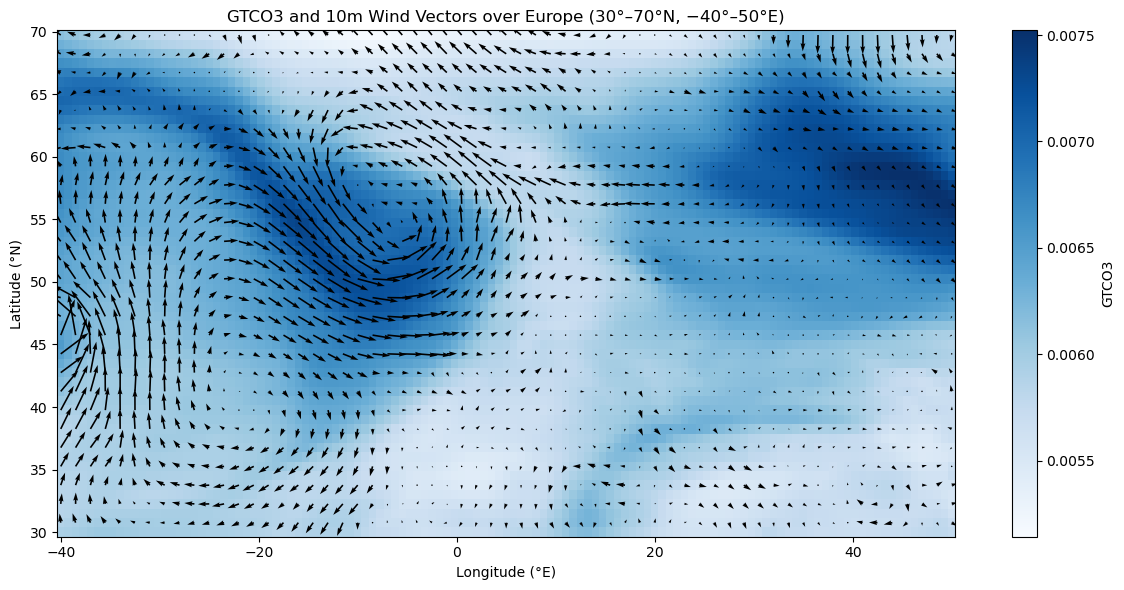

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr


# Time slice
time = 20

var = 'gtco3'
t2m_eur = ds[var].isel(valid_time=time)
u10_eur = ds["u10"].isel(valid_time=time)
v10_eur = ds["v10"].isel(valid_time=time)



# === Step 3: Create meshgrid and subsample for quiver ===
lon2d, lat2d = np.meshgrid(t2m_eur.longitude.values, t2m_eur.latitude.values)

# Subsample for clarity
step = 2
u_plot = u10_eur.values[::step, ::step]
v_plot = v10_eur.values[::step, ::step]
lon_plot = lon2d[::step, ::step]
lat_plot = lat2d[::step, ::step]

# === Step 4: Plot ===
plt.figure(figsize=(12, 6))
t2m_eur.plot(cmap='Blues', cbar_kwargs={"label": "GTCO3"})
plt.quiver(lon_plot, lat_plot, u_plot, v_plot, scale=600, width=0.0018, color='black')
plt.title("GTCO3 and 10m Wind Vectors over Europe (30°–70°N, −40°–50°E)")
plt.xlabel("Longitude (°E)")
plt.ylabel("Latitude (°N)")
plt.tight_layout()
plt.show()

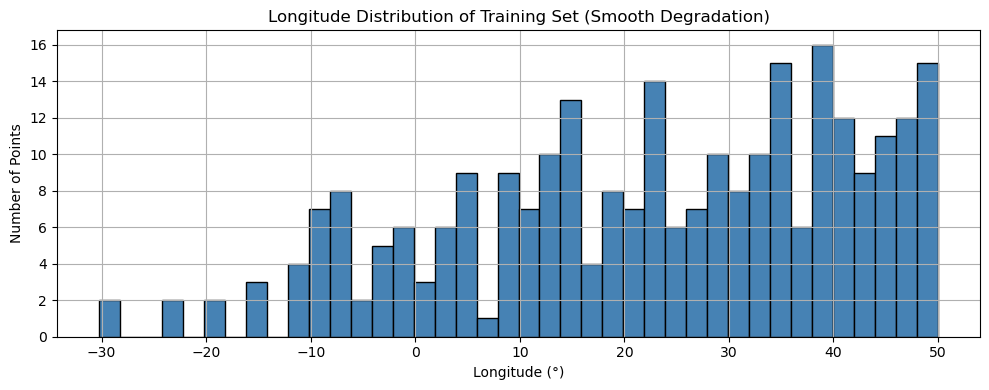

✅ Data generated and saved with smooth longitude-based training degradation.


In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import os
import matplotlib.pyplot as plt

target_variable = "gtco3"  # Change as needed (e.g., 't2m')

np.random.seed(41)

# Load dataset
ds_europe = xr.open_dataset("geo_data/data_sfc.nc")
ds_wind = xr.open_dataset("geo_data/data_sfc.nc")

# === Helper functions ===
def sph2cart(lat_deg, lon_deg):
    lat = np.radians(lat_deg)
    lon = np.radians(lon_deg)
    x = np.cos(lat) * np.cos(lon)
    y = np.cos(lat) * np.sin(lon)
    z = np.sin(lat)
    return x, y, z

def wind_to_cartesian(u, v, lat_deg, lon_deg):
    lat = np.radians(lat_deg)
    lon = np.radians(lon_deg)
    e_east = np.array([-np.sin(lon), np.cos(lon), 0.0])
    e_north = np.array([
        -np.sin(lat) * np.cos(lon),
        -np.sin(lat) * np.sin(lon),
        np.cos(lat)
    ])
    w = u * e_east + v * e_north
    return w[0], w[1], w[2]

# === Extract data ===
time = 20
lat = ds_europe.latitude.values
lon = ds_europe.longitude.values
lat_grid, lon_grid = np.meshgrid(lat, lon, indexing='ij')

lat_flat = lat_grid.flatten()
lon_flat = lon_grid.flatten()
msl_flat = ds_europe[target_variable].isel(valid_time=time).values.flatten()
u10_flat = ds_wind.u10.isel(valid_time=time).values.flatten()
v10_flat = ds_wind.v10.isel(valid_time=time).values.flatten()
N_total = len(lat_flat)

sin_theta_flat = np.sin(np.radians(90 - lat_flat))
u10_flat = u10_flat #/ (sin_theta_flat + 1e-12)

# === Convert wind to 3D Cartesian vectors ===
x_w, y_w, z_w = sph2cart(lat_flat, lon_flat)
wx, wy, wz = [], [], []
for i in range(N_total):
    vx, vy, vz = wind_to_cartesian(u10_flat[i], v10_flat[i], lat_flat[i], lon_flat[i])
    wx.append(vx)
    wy.append(vy)
    wz.append(vz)

wx, wy, wz = np.array(wx), np.array(wy), np.array(wz)
norm_max = np.max(np.sqrt(wx**2 + wy**2 + wz**2)) + 1e-10
wx /= norm_max
wy /= norm_max
wz /= norm_max

# === Save wind data ===
os.makedirs("data", exist_ok=True)
wind_df = pd.DataFrame({'x': x_w, 'y': y_w, 'z': z_w, 'wx': wx, 'wy': wy, 'wz': wz})
wind_df.to_csv("data/wind.csv", index=False)
wind_df.sample(frac=0.2, random_state=41).to_csv("data/wind_sub.csv", index=False)

# === Soft-Degrading Longitude-Based Training Sampling ===
temp_fraction = 0.1
train_prob = 0.02 + 0.98 * np.clip((lon_flat + 40) / 90, 0, 1) ** 1.5 # Soft preference for eastern region
is_train = np.random.rand(N_total) < train_prob * temp_fraction
train_indices = np.where(is_train)[0]
#train_indices = np.random.choice(N_total, int(N_total * temp_fraction), replace=False)

# === Independent Test Sampling ===
available_for_test = np.setdiff1d(np.arange(N_total), train_indices)
n_test = N_total // 5
test_indices = np.random.choice(available_for_test, n_test, replace=False)

# === Train/Test Coordinates and Targets ===
x_train, y_train, z_train = sph2cart(lat_flat[train_indices], lon_flat[train_indices])
train_target = msl_flat[train_indices]
x_test, y_test, z_test = sph2cart(lat_flat[test_indices], lon_flat[test_indices])
test_target = msl_flat[test_indices]

# === Normalize Target ===
min_val, max_val = train_target.min(), train_target.max()
train_target_norm = (train_target - min_val) / (max_val - min_val)
test_target_norm = (test_target - min_val) / (max_val - min_val)

# === Save Internal Train Splits ===
n_splits = 10
for i in range(n_splits):
    idx = np.random.permutation(len(train_target))
    n_val = len(idx) // 2
    val_idx = idx[:n_val]
    sub_train_idx = idx[n_val:]

    pd.DataFrame({
        'x': x_train[sub_train_idx],
        'y': y_train[sub_train_idx],
        'z': z_train[sub_train_idx]
    }).to_csv(f"data/train_locs_{i}.csv", index=True)

    pd.DataFrame({'target': train_target_norm[sub_train_idx]}).to_csv(f"data/train_response_{i}.csv", index=True)

# === Save Final Test Set ===
pd.DataFrame({'x': x_test, 'y': y_test, 'z': z_test}).to_csv("data/test_locs.csv", index=False)
pd.DataFrame({'target': test_target_norm}).to_csv("data/test_response.csv", index=False)

# === Plot: Longitude Histogram ===
plt.figure(figsize=(10, 4))
plt.hist(lon_flat[train_indices], bins=40, color="steelblue", edgecolor="black")
plt.title("Longitude Distribution of Training Set (Smooth Degradation)")
plt.xlabel("Longitude (°)")
plt.ylabel("Number of Points")
plt.grid(True)
plt.tight_layout()
plt.savefig("data/train_longitude_distribution.png", dpi=200)
plt.show()

print("✅ Data generated and saved with smooth longitude-based training degradation.")